In [2]:
#load dataset
import pandas as pd
df = pd.read_csv(r'C:\Users\aliza\Desktop\CV\0-DeployProjects\Equipment Analytics Dashboard\data\raw_data_predictive_maintenance.csv', encoding ='utf-8-sig')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
#check columsn again
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [4]:
#dataset shape
df.shape

(10000, 10)

In [5]:
#dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [6]:
#missing values
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [7]:
#statistical summary
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [8]:
#understand target variable
df["Target"].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [9]:
df["Target"].value_counts(normalize=True) * 100

Target
0    96.61
1     3.39
Name: proportion, dtype: float64

In [10]:
#failure type analysis
df["Failure Type"].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [12]:
df["Failure Type"].value_counts()
df.drop(columns=["UDI"], inplace=True)

In [13]:
#product type analysis
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [14]:
#compare with failures
pd.crosstab(df["Type"], df["Target"])

Target,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [15]:
#failure type with product category
pd.crosstab(df["Type"], df["Failure Type"])

Failure Type,Heat Dissipation Failure,No Failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Type,,,,,,
H,8,979,1,5,4,6
L,74,5757,73,59,12,25
M,30,2916,4,31,2,14


In [16]:
#numericxal failure summary by feature
df.groupby("Target")[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Target,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [17]:
#correlation analysis
numeric_df = df.select_dtypes(include='number')

In [18]:
numeric_df.corr()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Target,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

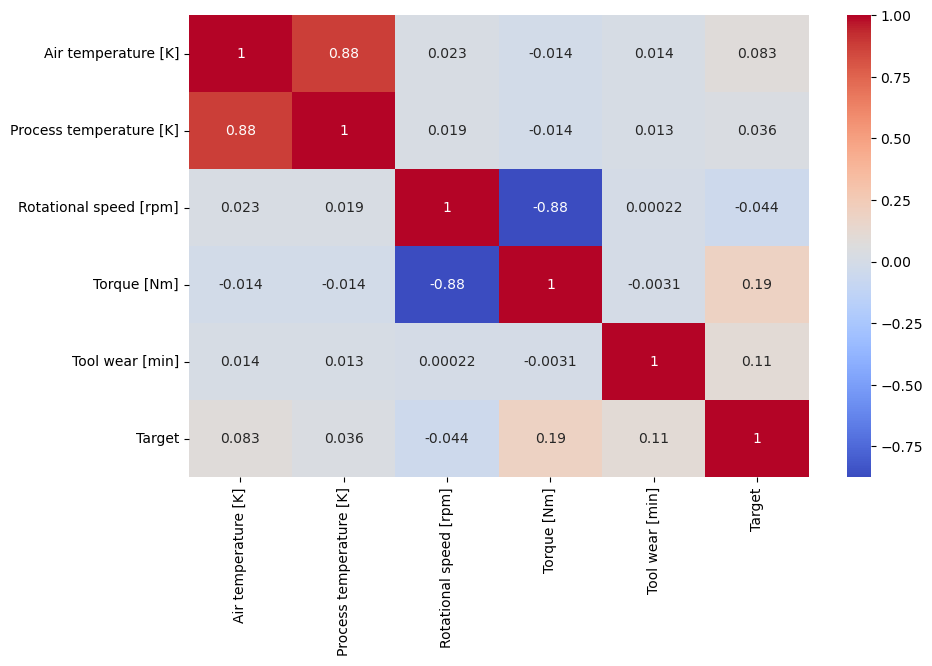

In [21]:
#visualize correlation
plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.show()

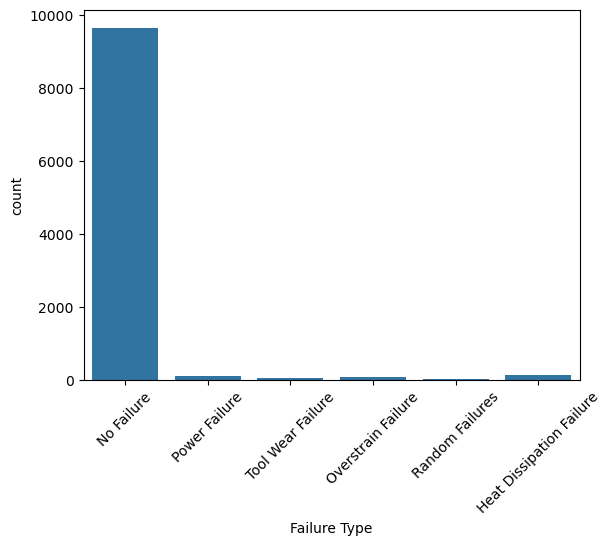

In [22]:
#failure count plot
sns.countplot(x="Failure Type", data=df)

plt.xticks(rotation=45)

plt.show()

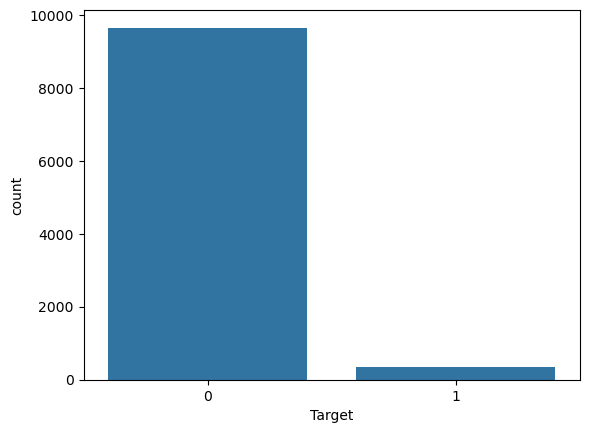

In [23]:
#target distribution
sns.countplot(x="Target", data=df)

plt.show()

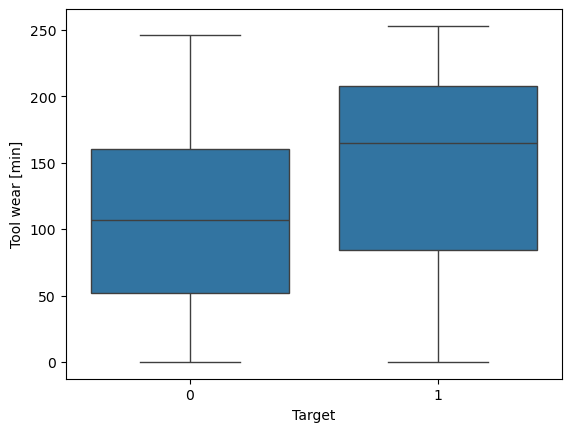

In [24]:
#tool weae vs failure
sns.boxplot(x="Target", y="Tool wear [min]", data=df)

plt.show()

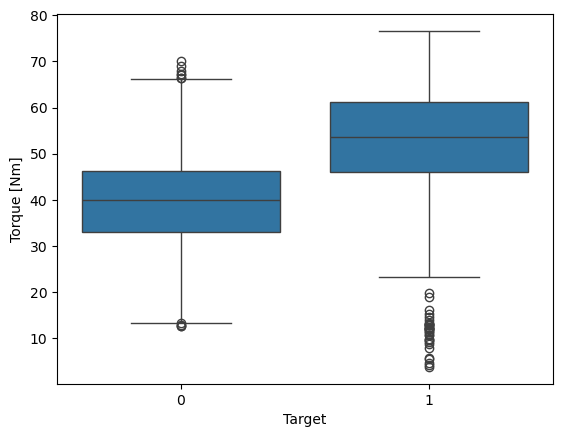

In [25]:
#torque vs failure
sns.boxplot(x="Target", y="Torque [Nm]", data=df)

plt.show()

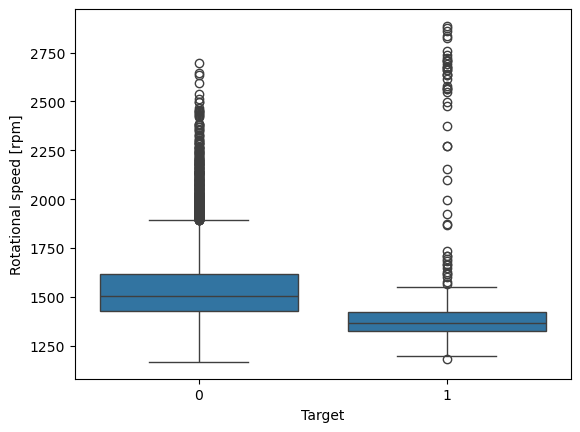

In [26]:
#rpm vs failure
sns.boxplot(x="Target", y="Rotational speed [rpm]", data=df)

plt.show()

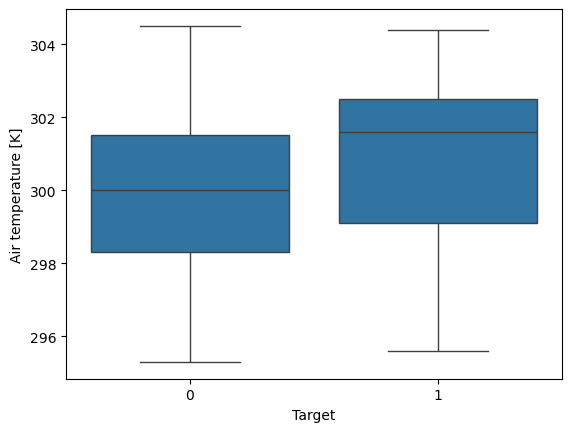

In [27]:
#temperature vs failure
sns.boxplot(x="Target", y="Air temperature [K]", data=df)

plt.show()

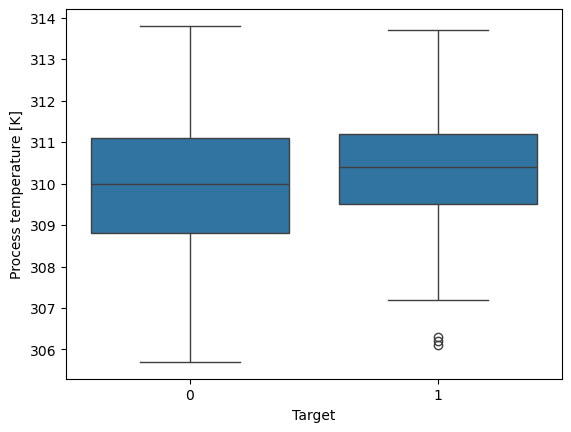

In [28]:
#process temperature
sns.boxplot(x="Target", y="Process temperature [K]", data=df)

plt.show()

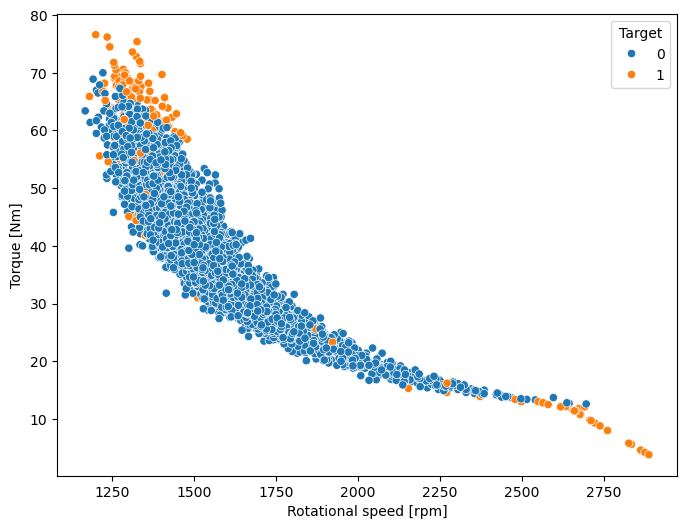

In [29]:
#scatter plot- torque vs rpm
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Target",
    data=df
)

plt.show()

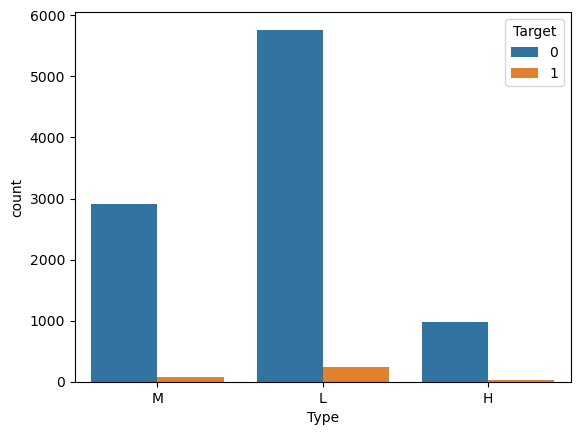

In [30]:
#product type failure comparison
sns.countplot(x="Type", hue="Target", data=df)

plt.show()

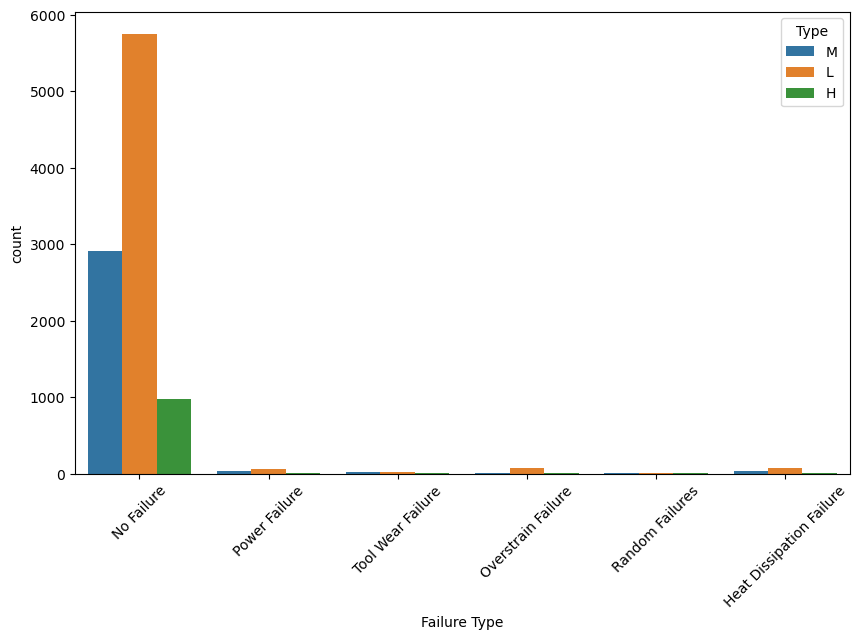

In [31]:
#failure type by product category
plt.figure(figsize=(10,6))

sns.countplot(x="Failure Type", hue="Type", data=df)

plt.xticks(rotation=45)

plt.show()

In [32]:
#failure rate by product type
failure_rate = pd.crosstab(
    df["Type"],
    df["Target"],
    normalize="index"
) * 100

failure_rate

Target,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


In [33]:
#Average Operating Conditions for Each Failure Type
df.groupby("Failure Type")[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Failure Type,,,,,
Heat Dissipation Failure,302.567857,310.799107,1337.964286,52.778571,107.339286
No Failure,299.972855,309.994343,1540.324389,39.624316,106.678927
Overstrain Failure,299.867949,310.051282,1354.243590,56.878205,208.217949
Power Failure,300.075789,309.954737,1763.968421,48.514737,101.884211
Random Failures,300.766667,310.755556,1489.444444,43.522222,119.888889
Tool Wear Failure,300.288889,310.164444,1570.666667,37.226667,216.555556


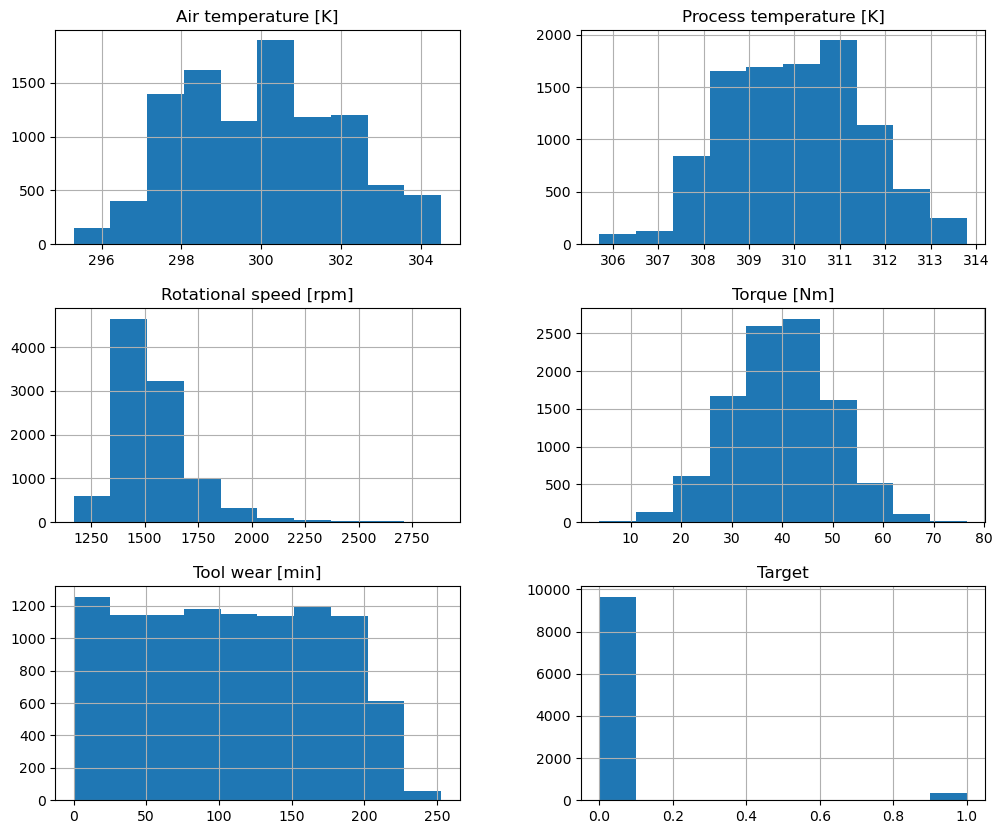

In [34]:
#distribution plot
df.hist(figsize=(12,10))

plt.show()

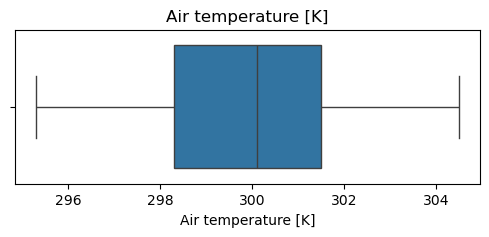

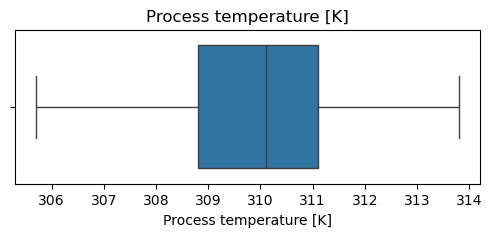

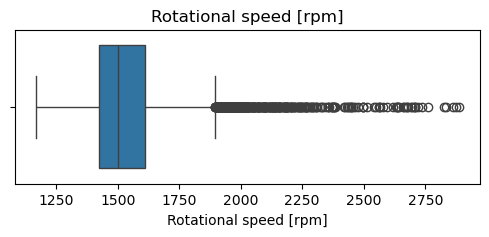

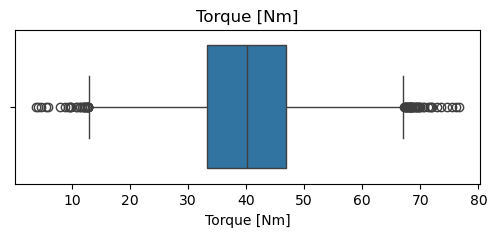

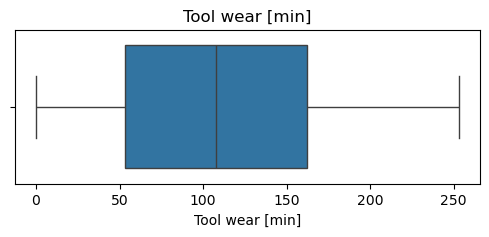

In [35]:
#outlier detection
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in numeric_columns:
    
    plt.figure(figsize=(6,2))
    
    sns.boxplot(x=df[col])
    
    plt.title(col)
    
    plt.show()

In [37]:
# rename columns

df.columns = [
    "product_id",
    "type",
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "target",
    "failure_type"
]

In [38]:
#verify again
df.columns

Index(['product_id', 'type', 'air_temp_k', 'process_temp_k',
       'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'target',
       'failure_type'],
      dtype='object')

In [ ]:
############################## PHASE 1 FINISHING WITH EDA ##############################################

In [39]:
#Missing Values Check
df.isnull().sum()

product_id              0
type                    0
air_temp_k              0
process_temp_k          0
rotational_speed_rpm    0
torque_nm               0
tool_wear_min           0
target                  0
failure_type            0
dtype: int64

In [40]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

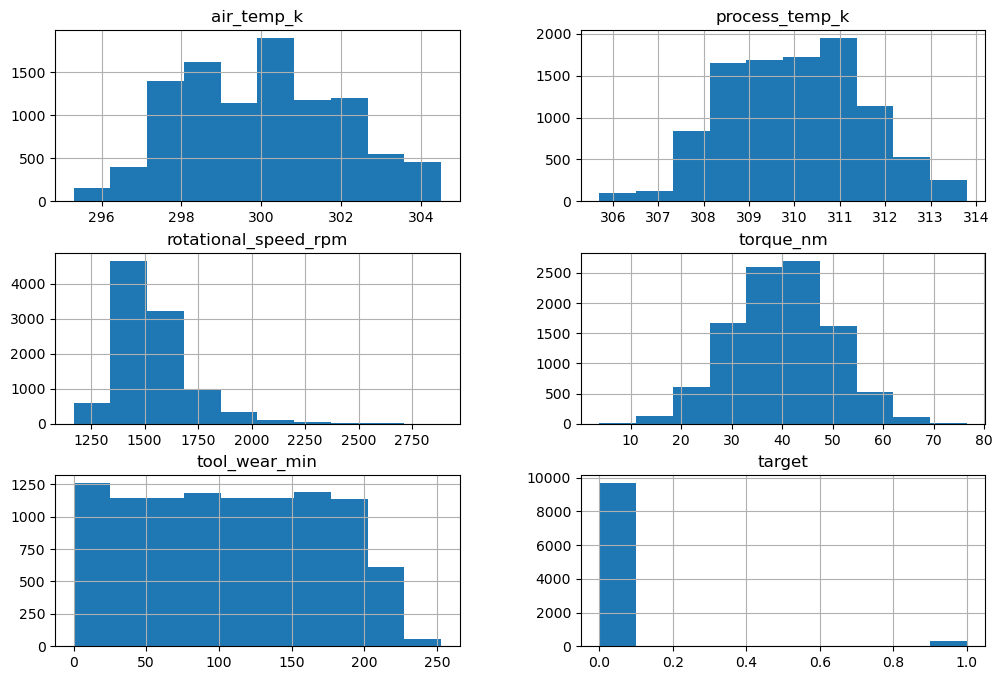

In [41]:
#Distribution analysis
df.hist(figsize=(12,8))
plt.show()

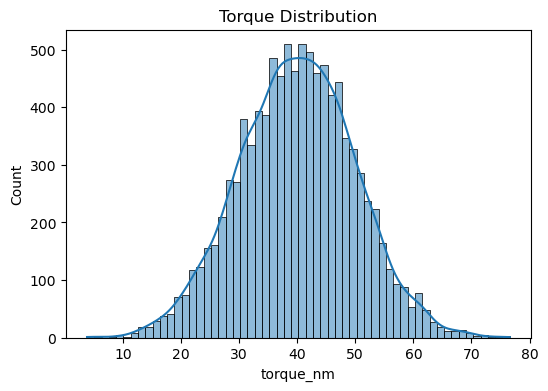

In [43]:
#individual histogram
plt.figure(figsize=(6,4))

sns.histplot(df["torque_nm"], kde=True)

plt.title("Torque Distribution")

plt.show()

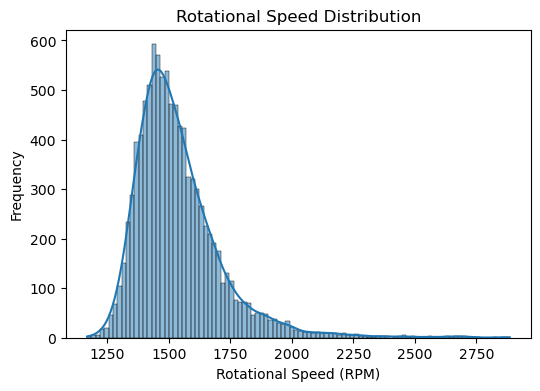

In [44]:
# Rotational Speed Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["rotational_speed_rpm"], kde=True)

plt.title("Rotational Speed Distribution")

plt.xlabel("Rotational Speed (RPM)")

plt.ylabel("Frequency")

plt.show()

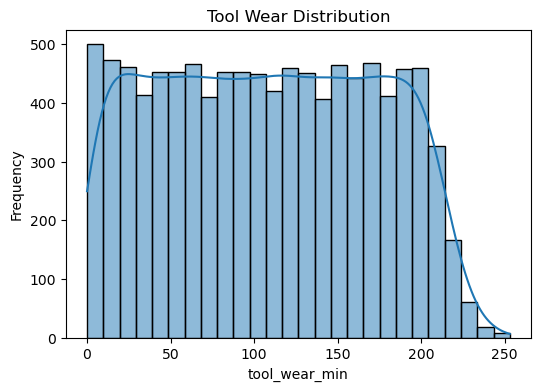

In [45]:
#INDIVIDUAL HISTOGRAM
# Tool Wear Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["tool_wear_min"], kde=True)

plt.title("Tool Wear Distribution")

plt.xlabel("tool_wear_min")

plt.ylabel("Frequency")

plt.show()

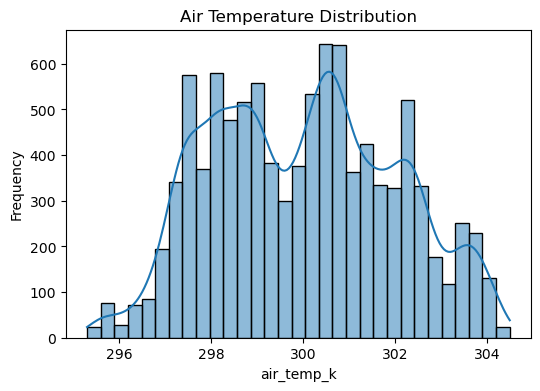

In [46]:
#INDIVIDUAL HISTOGRAM
# Air Temperature Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["air_temp_k"], kde=True)

plt.title("Air Temperature Distribution")

plt.xlabel("air_temp_k")

plt.ylabel("Frequency")

plt.show()

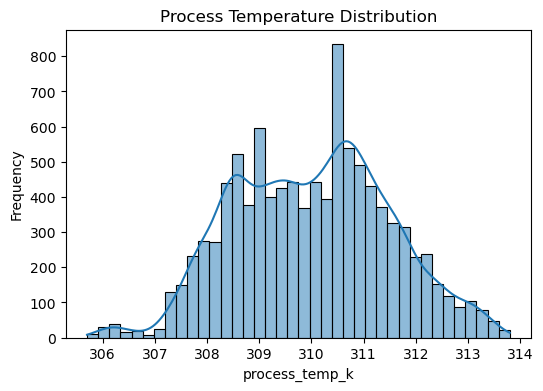

In [47]:
#INDIVIDUAL HISTOGRAM
# Process Temperature Distribution
plt.figure(figsize=(6,4))

sns.histplot(df["process_temp_k"], kde=True)

plt.title("Process Temperature Distribution")

plt.xlabel("process_temp_k")

plt.ylabel("Frequency")

plt.show()

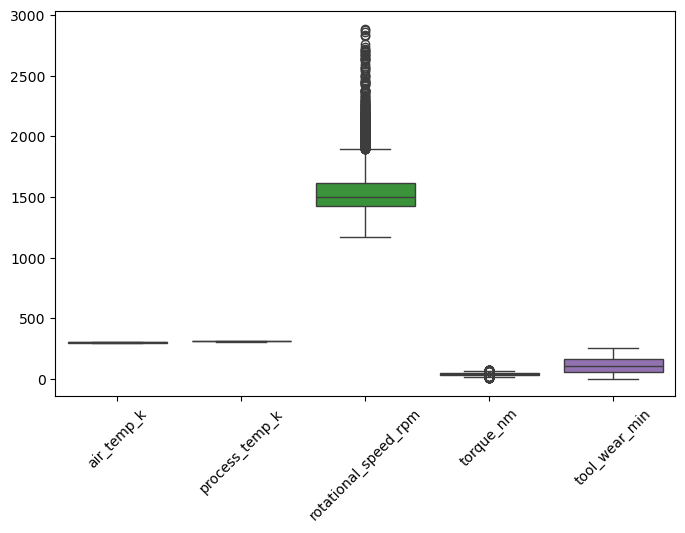

In [48]:
#outlier visualization
plt.figure(figsize=(8,5))

sns.boxplot(data=df[[
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min"
]])

plt.xticks(rotation=45)

plt.show()

In [ ]:
######################################### PHASE 2 FEATURE ENGINEERING ###################################

In [50]:
#feature engineering
#temperature difference feature
df["Temperature Difference"] = (
    df["process_temp_k"]
    - df["air_temp_k"]
)
df[["process_temp_k", "air_temp_k", "Temperature Difference"]].head()

,process_temp_k,air_temp_k,Temperature Difference
0,308.6,298.1,10.5
1,308.7,298.2,10.5
2,308.5,298.1,10.4
3,308.6,298.2,10.4
4,308.7,298.2,10.5


In [51]:
#wear per torque ratio
#wear stress ratio
#wear stress ratio
df["wear_torque_ratio"] = (
    df["tool_wear_min"]
    / df["torque_nm"]
)
df[["tool_wear_min", "torque_nm", "wear_torque_ratio"]].head()

,tool_wear_min,torque_nm,wear_torque_ratio
0,0,42.8,0.000000
1,3,46.3,0.064795
2,5,49.4,0.101215
3,7,39.5,0.177215
4,9,40.0,0.225000


In [52]:
#high risk flag
#create risk category
#create risk category
df["risk_level"] = df["target"].map({
    0: "Low Risk",
    1: "High Risk"
})
df[["target", "risk_level"]].head()

,target,risk_level
0,0,Low Risk
1,0,Low Risk
2,0,Low Risk
3,0,Low Risk
4,0,Low Risk


In [54]:
#equipment age category
import numpy as np

df["equipment_age_years"] = np.random.randint(
    1,
    15,
    size=len(df)
)
df[["equipment_age_years"]].head()

,equipment_age_years
0,9
1,10
2,8
3,12
4,7


In [55]:
df.groupby("target")["equipment_age_years"].mean()

target
0    7.394162
1    7.407080
Name: equipment_age_years, dtype: float64

In [57]:
#simulate maintenance dates
#simulate maintenance dates
df["maintenance_date"] = pd.date_range(
    start="2024-01-01",
    periods=len(df),
    freq="h"
)
df[["maintenance_date"]].head()

,maintenance_date
0,2024-01-01 00:00:00
1,2024-01-01 01:00:00
2,2024-01-01 02:00:00
3,2024-01-01 03:00:00
4,2024-01-01 04:00:00


In [ ]:
####################### PHASE 3 KPI CALCULATION ###############################################3

In [59]:
#FAILURE RATE
#failure rate
failure_rate = (
    df["target"].mean() * 100
)

print(f"Failure Rate: {failure_rate:.2f}%")

Failure Rate: 3.39%


In [60]:
#AVERAGE TORQUE
#AVERAGE TORQUE
avg_torque = df["torque_nm"].mean()

print(f"Average Torque: {avg_torque:.2f} Nm")

Average Torque: 39.99 Nm


In [61]:
#AVERAGE TOOL WEAR
#AVERAGE TOOL WEAR
avg_wear = df["tool_wear_min"].mean()

print(f"Average Tool Wear: {avg_wear:.2f} min")

Average Tool Wear: 107.95 min


In [62]:
#HIGH RISK EQUIPMENT COUNT
high_risk = df[df["target"] == 1].shape[0]

print(f"High Risk Equipment Count: {high_risk}")

High Risk Equipment Count: 339


In [63]:
#FAILURE COUNT BY TYPE
failure_by_type = (
    df.groupby("failure_type")["target"]
    .sum()
    .sort_values(ascending=False)
)

print(failure_by_type)

failure_type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
No Failure                    9
Random Failures               0
Name: target, dtype: int64


In [ ]:
############################### PHASE 4 SQL READY DATASET ##################################

In [64]:
#SAVE FINAL DATASET
df.to_csv(
    "../data/cleaned_equipment_data.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
########################## PHASE 5 SQLITE INTEGRATION #########################################

In [65]:
#IMPORT SQLITE
import sqlite3
import pandas as pd

In [66]:
#Create/connect SQLite database
conn = sqlite3.connect(
    "../database/equipment_analytics.db"
)

In [67]:
#EXPORT TABLE/Save dataframe into SQLite table
df.to_sql(
    "equipment_data",
    conn,
    if_exists="replace",
    index=False
)

10000

In [69]:
#verify
query = """
SELECT COUNT(*) AS total_rows
FROM equipment_data;
"""

pd.read_sql(query, conn)

,total_rows
0,10000


In [70]:
#verify tables
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, conn)

,name
0,equipment_data


In [71]:
#verify axtual table contents
query = """
SELECT *
FROM equipment_data
LIMIT 5;
"""

pd.read_sql(query, conn)

,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,failure_type,Temperature Difference,wear_torque_ratio,risk_level,equipment_age_years,maintenance_date
0,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,0.000000,Low Risk,9,2024-01-01 00:00:00
1,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,0.064795,Low Risk,10,2024-01-01 01:00:00
2,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,0.101215,Low Risk,8,2024-01-01 02:00:00
3,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,0.177215,Low Risk,12,2024-01-01 03:00:00
4,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,0.225000,Low Risk,7,2024-01-01 04:00:00


In [72]:
query = """
SELECT *
FROM equipment_data
LIMIT 5;
"""

pd.read_sql(query, conn)

,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,failure_type,Temperature Difference,wear_torque_ratio,risk_level,equipment_age_years,maintenance_date
0,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,10.5,0.000000,Low Risk,9,2024-01-01 00:00:00
1,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,10.5,0.064795,Low Risk,10,2024-01-01 01:00:00
2,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,10.4,0.101215,Low Risk,8,2024-01-01 02:00:00
3,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,10.4,0.177215,Low Risk,12,2024-01-01 03:00:00
4,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,10.5,0.225000,Low Risk,7,2024-01-01 04:00:00


In [73]:
#TOP FAILURE TYPES
query = """
SELECT failure_type,
       COUNT(*) AS total_failures
FROM equipment_data
WHERE target = 1
GROUP BY failure_type
ORDER BY total_failures DESC;
"""

pd.read_sql(query, conn)

,failure_type,total_failures
0,Heat Dissipation Failure,112
1,Power Failure,95
2,Overstrain Failure,78
3,Tool Wear Failure,45
4,No Failure,9


In [74]:
#AVERAGE TORQUE BY RISK LEVEL
query = """
SELECT risk_level,
       AVG(torque_nm) AS avg_torque
FROM equipment_data
GROUP BY risk_level;
"""

pd.read_sql(query, conn)

,risk_level,avg_torque
0,High Risk,50.168142
1,Low Risk,39.629655


In [75]:
#TOP 10 HIGHEST TOOL WEAR EQUIPMENT
query = """
SELECT product_id,
       tool_wear_min
FROM equipment_data
ORDER BY tool_wear_min DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,product_id,tool_wear_min
0,M20261,253
1,L52580,251
2,H32278,246
3,H34813,246
4,L56851,246
5,L50043,244
6,L52578,244
7,L56850,244
8,L50042,242
9,L56849,242


In [76]:
#CHECK INCONSISTENT ROWS
df[
    (df["target"] == 1) &
    (df["failure_type"] == "No Failure")
]

,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,target,failure_type,Temperature Difference,wear_torque_ratio,risk_level,equipment_age_years,maintenance_date
1437,H30851,H,298.8,309.9,1439,45.2,40,1,No Failure,11.1,0.884956,High Risk,14,2024-02-29 21:00:00
2749,M17609,M,299.7,309.2,1685,28.9,179,1,No Failure,9.5,6.193772,High Risk,9,2024-04-24 13:00:00
4044,M18904,M,301.9,310.9,1419,47.7,20,1,No Failure,9.0,0.419287,High Risk,4,2024-06-17 12:00:00
4684,M19544,M,303.6,311.8,1421,44.8,101,1,No Failure,8.2,2.254464,High Risk,3,2024-07-14 04:00:00
5536,M20396,M,302.3,311.8,1363,54.0,119,1,No Failure,9.5,2.203704,High Risk,3,2024-08-18 16:00:00
5941,L53121,L,300.6,310.7,1438,48.5,78,1,No Failure,10.1,1.608247,High Risk,4,2024-09-04 13:00:00
6478,L53658,L,300.5,309.8,1663,29.1,145,1,No Failure,9.3,4.982818,High Risk,6,2024-09-26 22:00:00
8506,L55686,L,298.4,309.6,1710,27.3,163,1,No Failure,11.2,5.970696,High Risk,14,2024-12-20 10:00:00
9015,L56195,L,297.2,308.1,1431,49.7,210,1,No Failure,10.9,4.225352,High Risk,13,2025-01-10 15:00:00


In [77]:
#REMOVE INVALID ROWS
df = df[
    ~(
        (df["target"] == 1) &
        (df["failure_type"] == "No Failure")
    )
]

In [78]:
#SAVE CLEANED DATA AGAIN
df.to_sql(
    "equipment_data",
    conn,
    if_exists="replace",
    index=False
)

9991

In [79]:
#TOP FAILURE TYPES
query = """
SELECT failure_type,
       COUNT(*) AS total_failures
FROM equipment_data
WHERE target = 1
GROUP BY failure_type
ORDER BY total_failures DESC;
"""

pd.read_sql(query, conn)

,failure_type,total_failures
0,Heat Dissipation Failure,112
1,Power Failure,95
2,Overstrain Failure,78
3,Tool Wear Failure,45


In [80]:
#SAVE FINAL CLEAN DATASET
df.to_csv(
    r"C:\Users\aliza\Desktop\CV\0-DeployProjects\Equipment Analytics Dashboard\data\cleaned_equipment_data.csv",
    index=False
)